In [1]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns

## Reading log files and selecting the line with CV

In [2]:
log_files = glob.glob("log*.out")
log_files

['log7.out',
 'log12.out',
 'log8.out',
 'log10.out',
 'log1.out',
 'log6.out',
 'log9.out',
 'log13.out',
 'log14.out',
 'log4.out',
 'log11.out',
 'log3.out',
 'log15.out',
 'log2.out',
 'log5.out']

In [4]:
LF = []
for lf in log_files:
    fh = open(lf, "r")
    linie = fh.readlines()
    k = [(ele.split()[2],ele.split()[3]) for ele in linie if "CV" in ele]
    kf = [[int(ele[0].split('=')[1].split(')')[0]), ele[1]] for ele in k][0]
    LF.append(kf)
dL = pd.DataFrame(LF, columns = ['K','CV']).sort_values(by = "K").reset_index(drop=True)
dL['CV'] = dL['CV'].astype('float')
dL['K'] = dL['K'].astype('int')
dL.head()

,K,CV
0,1,0.53705
1,2,0.51097
2,3,0.49130
3,4,0.48835
4,5,0.48236


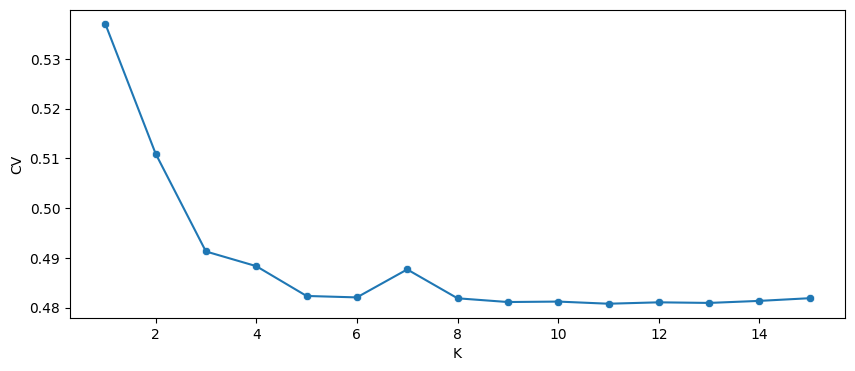

In [5]:
fig, ax = plt.subplots(figsize = (10,4))
sns.scatterplot(data = dL, x = 'K', y = 'CV', ax=ax)
sns.lineplot(data = dL, x = 'K', y = 'CV', ax=ax)

plt.savefig("admixture_04_combine_output_CV.png", dpi=150)

In [6]:
dL

,K,CV
0,1,0.53705
1,2,0.51097
2,3,0.49130
3,4,0.48835
4,5,0.48236
5,6,0.48207
6,7,0.48769
7,8,0.48189
8,9,0.48114
9,10,0.48123


In [7]:
dL.to_csv("admixture_04_combine_output_CV.out", sep="\t", header=True, index=False)
dL.head()

,K,CV
0,1,0.53705
1,2,0.51097
2,3,0.49130
3,4,0.48835
4,5,0.48236


## Reading admixture tables and pasting them together

In [8]:
tabs = glob.glob("admixture_01_input.*.Q")
R = []
for k in range(1,16):
    tab = "admixture_01_input."+str(k)+".Q"
    dt = pd.read_csv(tab, sep=" ", header=None)
    #k = tab.split(".")[-2]
    col_names = dt.columns.values.tolist()
    col_names_new = ["K"+str(k)+".Q"+str(ele) for ele in col_names]
    dt.columns = col_names_new
    R.append(dt)
dR = pd.concat(R, axis=1)
dR.head()

,K1.Q0,K2.Q0,K2.Q1,K3.Q0,K3.Q1,K3.Q2,K4.Q0,K4.Q1,K4.Q2,K4.Q3,...,K15.Q5,K15.Q6,K15.Q7,K15.Q8,K15.Q9,K15.Q10,K15.Q11,K15.Q12,K15.Q13,K15.Q14
0,1.0,0.093658,0.906342,0.984298,0.000484,0.015218,0.902459,0.000010,0.000466,0.097065,...,0.189746,0.000010,0.127704,0.010999,0.000010,0.002490,0.000010,0.000010,0.053654,0.000010
1,1.0,0.142411,0.857589,0.946506,0.000010,0.053484,0.976856,0.023124,0.000010,0.000010,...,0.048671,0.000010,0.000010,0.028390,0.000010,0.000010,0.020126,0.043230,0.000010,0.024345
2,1.0,0.118712,0.881288,0.965902,0.000010,0.034088,0.994834,0.005146,0.000010,0.000010,...,0.148287,0.001511,0.022221,0.005926,0.003103,0.000010,0.004263,0.023996,0.000010,0.007721
3,1.0,0.065449,0.934551,0.973082,0.021766,0.005152,0.210664,0.010010,0.002862,0.776465,...,0.032518,0.013361,0.033140,0.000010,0.000010,0.006404,0.000010,0.003019,0.283604,0.026180
4,1.0,0.999990,0.000010,0.003329,0.000010,0.996661,0.000010,0.995535,0.000010,0.004445,...,0.000010,0.093072,0.000010,0.000010,0.000010,0.000010,0.276856,0.000010,0.000010,0.000010


In [9]:
dR.shape

(2322, 120)

## Adding sample data

In [10]:
fam = pd.read_csv("admixture_01_input.fam", sep=" ", header=None, usecols=[1], names=["sample"])
dmeta = pd.read_csv("../01_snp_treatment/04_merging_metadata.tsv",
                    sep="\t", header=0, usecols = ["id","POP","STRATA","SPECIES_ID","BATCH_ID","lon","lat"])
dmeta.head()
dM = pd.merge(fam, dmeta, left_on = "sample", right_on = "id", how = "left")
dM.head()
mR = pd.concat([dM, dR], axis=1)
print(fam.shape, dmeta.shape, dM.shape, dR.shape, mR.shape)
mR.head()

(2322, 1) (2322, 7) (2322, 8) (2322, 120) (2322, 128)


,sample,id,SPECIES_ID,BATCH_ID,POP,STRATA,lat,lon,K1.Q0,K2.Q0,...,K15.Q5,K15.Q6,K15.Q7,K15.Q8,K15.Q9,K15.Q10,K15.Q11,K15.Q12,K15.Q13,K15.Q14
0,E353-B1_3_6_333_001,E353-B1_3_6_333_001,EPN,DSpr18-3269,333,G,49.616667,-77.750000,1.0,0.093658,...,0.189746,0.000010,0.127704,0.010999,0.000010,0.002490,0.000010,0.000010,0.053654,0.000010
1,E353-B1_3_6_6914_073,E353-B1_3_6_6914_073,EPN,DSpr18-3269,6914,F,48.633333,-85.333333,1.0,0.142411,...,0.048671,0.000010,0.000010,0.028390,0.000010,0.000010,0.020126,0.043230,0.000010,0.024345
2,E353-B1_3_16_6917_081,E353-B1_3_16_6917_081,EPN,DSpr18-3269,6917,E,49.000000,-90.450000,1.0,0.118712,...,0.148287,0.001511,0.022221,0.005926,0.003103,0.000010,0.004263,0.023996,0.000010,0.007721
3,E353-B3_3_7_6802_478,E353-B3_3_7_6802_478,EPN,DSpr18-3269,6802,I,48.216667,-58.916667,1.0,0.065449,...,0.032518,0.013361,0.033140,0.000010,0.000010,0.006404,0.000010,0.003019,0.283604,0.026180
4,E353-B3_3_14_6986_371,E353-B3_3_14_6986_371,EPN,DSpr18-3269,6986,C,56.616667,-121.466667,1.0,0.999990,...,0.000010,0.093072,0.000010,0.000010,0.000010,0.000010,0.276856,0.000010,0.000010,0.000010


In [35]:
mR.to_csv("admixture_04_combine_output_admixture.tsv", sep="\t", header=True, index=False)

In [11]:
fam.shape
mR.shape

(2322, 128)

# Selecting best cluster for each sample for K5 and K6

In [12]:
Admixture_dict = {'K6.Q0':'K6.East',
                  'K6.Q1':'K6.WI',
                  'K6.Q2':'K6.RedSpruce',
                  'K6.Q3':'K6.West',
                  'K6.Q4':'K6.Central',
                  'K6.Q5':'K6.WhiteSpruce',
                  'K5.Q0':'K5.Central',
                  'K5.Q1':'K5.RedSpruce',
                  'K5.Q2':'K5.West',
                  'K5.Q3':'K5.East',
                  'K5.Q4':'K5.WhiteSpruce'}

In [13]:
def selectBest(series):
    highest_index = series.sort_values(ascending=False).index[0]
    highest_value = series[highest_index]
    return(Admixture_dict[highest_index], highest_value)

In [14]:
mR.head()

,sample,id,SPECIES_ID,BATCH_ID,POP,STRATA,lat,lon,K1.Q0,K2.Q0,...,K15.Q5,K15.Q6,K15.Q7,K15.Q8,K15.Q9,K15.Q10,K15.Q11,K15.Q12,K15.Q13,K15.Q14
0,E353-B1_3_6_333_001,E353-B1_3_6_333_001,EPN,DSpr18-3269,333,G,49.616667,-77.750000,1.0,0.093658,...,0.189746,0.000010,0.127704,0.010999,0.000010,0.002490,0.000010,0.000010,0.053654,0.000010
1,E353-B1_3_6_6914_073,E353-B1_3_6_6914_073,EPN,DSpr18-3269,6914,F,48.633333,-85.333333,1.0,0.142411,...,0.048671,0.000010,0.000010,0.028390,0.000010,0.000010,0.020126,0.043230,0.000010,0.024345
2,E353-B1_3_16_6917_081,E353-B1_3_16_6917_081,EPN,DSpr18-3269,6917,E,49.000000,-90.450000,1.0,0.118712,...,0.148287,0.001511,0.022221,0.005926,0.003103,0.000010,0.004263,0.023996,0.000010,0.007721
3,E353-B3_3_7_6802_478,E353-B3_3_7_6802_478,EPN,DSpr18-3269,6802,I,48.216667,-58.916667,1.0,0.065449,...,0.032518,0.013361,0.033140,0.000010,0.000010,0.006404,0.000010,0.003019,0.283604,0.026180
4,E353-B3_3_14_6986_371,E353-B3_3_14_6986_371,EPN,DSpr18-3269,6986,C,56.616667,-121.466667,1.0,0.999990,...,0.000010,0.093072,0.000010,0.000010,0.000010,0.000010,0.276856,0.000010,0.000010,0.000010


In [15]:
mR[['BestK6','BestK6_Q']] = mR[['K6.Q0', 'K6.Q1', 'K6.Q2', 'K6.Q3', 'K6.Q4', 'K6.Q5']].apply(lambda x: pd.Series(selectBest(x)), axis=1)
mR[['BestK5','BestK5_Q']] = mR[['K5.Q0', 'K5.Q1', 'K5.Q2', 'K5.Q3', 'K5.Q4']].apply(lambda x: pd.Series(selectBest(x)), axis=1)
mR.head()

,sample,id,SPECIES_ID,BATCH_ID,POP,STRATA,lat,lon,K1.Q0,K2.Q0,...,K15.Q9,K15.Q10,K15.Q11,K15.Q12,K15.Q13,K15.Q14,BestK6,BestK6_Q,BestK5,BestK5_Q
0,E353-B1_3_6_333_001,E353-B1_3_6_333_001,EPN,DSpr18-3269,333,G,49.616667,-77.750000,1.0,0.093658,...,0.000010,0.002490,0.000010,0.000010,0.053654,0.000010,K6.Central,0.933691,K5.Central,0.913010
1,E353-B1_3_6_6914_073,E353-B1_3_6_6914_073,EPN,DSpr18-3269,6914,F,48.633333,-85.333333,1.0,0.142411,...,0.000010,0.000010,0.020126,0.043230,0.000010,0.024345,K6.Central,0.922854,K5.Central,0.976944
2,E353-B1_3_16_6917_081,E353-B1_3_16_6917_081,EPN,DSpr18-3269,6917,E,49.000000,-90.450000,1.0,0.118712,...,0.003103,0.000010,0.004263,0.023996,0.000010,0.007721,K6.Central,0.958702,K5.Central,0.992039
3,E353-B3_3_7_6802_478,E353-B3_3_7_6802_478,EPN,DSpr18-3269,6802,I,48.216667,-58.916667,1.0,0.065449,...,0.000010,0.006404,0.000010,0.003019,0.283604,0.026180,K6.East,0.754297,K5.East,0.778339
4,E353-B3_3_14_6986_371,E353-B3_3_14_6986_371,EPN,DSpr18-3269,6986,C,56.616667,-121.466667,1.0,0.999990,...,0.000010,0.000010,0.276856,0.000010,0.000010,0.000010,K6.West,0.994747,K5.West,0.995028


# Adding call rates

In [17]:
subM = mR[["id","POP","STRATA","SPECIES_ID","BATCH_ID","lon","lat","BestK6","BestK6_Q","BestK5", "BestK5_Q"]].reset_index(drop=True)
cr = pd.read_csv("../01_snp_treatment/06_filtering_TOT_sample_metrics.tsv", sep='\t', usecols = ['id', 'call_rate'])

mM = pd.merge(subM, cr, on="id", how="left")
print(subM.shape, cr.shape, mM.shape)
mM.to_csv("admixture_04_combine_output_assigned_clusters.tsv", sep="\t", header=True, index=False)
mM.head()

(2322, 11) (2322, 2) (2322, 12)


,id,POP,STRATA,SPECIES_ID,BATCH_ID,lon,lat,BestK6,BestK6_Q,BestK5,BestK5_Q,call_rate
0,E353-B1_3_6_333_001,333,G,EPN,DSpr18-3269,-77.750000,49.616667,K6.Central,0.933691,K5.Central,0.913010,0.939222
1,E353-B1_3_6_6914_073,6914,F,EPN,DSpr18-3269,-85.333333,48.633333,K6.Central,0.922854,K5.Central,0.976944,0.914169
2,E353-B1_3_16_6917_081,6917,E,EPN,DSpr18-3269,-90.450000,49.000000,K6.Central,0.958702,K5.Central,0.992039,0.910718
3,E353-B3_3_7_6802_478,6802,I,EPN,DSpr18-3269,-58.916667,48.216667,K6.East,0.754297,K5.East,0.778339,0.915000
4,E353-B3_3_14_6986_371,6986,C,EPN,DSpr18-3269,-121.466667,56.616667,K6.West,0.994747,K5.West,0.995028,0.939222


In [18]:
mM[mM['BestK5'] == 'K5.WhiteSpruce']

,id,POP,STRATA,SPECIES_ID,BATCH_ID,lon,lat,BestK6,BestK6_Q,BestK5,BestK5_Q,call_rate
662,2388_CT_B1_R1,NaN,X,UNK,NaN,NaN,NaN,K6.WhiteSpruce,0.999950,K5.WhiteSpruce,0.999960,0.777146
663,77111_CT_B5_R1,NaN,X,UNK,NaN,NaN,NaN,K6.WhiteSpruce,0.999948,K5.WhiteSpruce,0.999960,0.783217
664,2388_CT_B5_R2,NaN,X,UNK,NaN,NaN,NaN,K6.WhiteSpruce,0.999949,K5.WhiteSpruce,0.999953,0.780054
665,77111_CT_B2_R1,NaN,X,UNK,NaN,NaN,NaN,K6.WhiteSpruce,0.999946,K5.WhiteSpruce,0.999960,0.721640
1583,E070-40,NaN,X,UNK,NaN,NaN,NaN,K6.WhiteSpruce,0.999942,K5.WhiteSpruce,0.999960,0.824855
1584,E070-90,NaN,X,UNK,NaN,NaN,NaN,K6.WhiteSpruce,0.999945,K5.WhiteSpruce,0.999951,0.779351
1593,EPO-5435,NaN,X,UNK,NaN,NaN,NaN,K6.WhiteSpruce,0.826254,K5.WhiteSpruce,0.826263,0.651051
1595,E070-73,NaN,X,UNK,NaN,NaN,NaN,K6.WhiteSpruce,0.999947,K5.WhiteSpruce,0.999960,0.831981
1596,E070-21,NaN,X,UNK,NaN,NaN,NaN,K6.WhiteSpruce,0.999946,K5.WhiteSpruce,0.999960,0.778680
1605,EPO-5392,NaN,X,UNK,NaN,NaN,NaN,K6.WhiteSpruce,0.852455,K5.WhiteSpruce,0.852450,0.612546


# List of samples

In [29]:
mM_filtered = mM[(mM['BestK5'] != 'K5.WhiteSpruce') & (mM['SPECIES_ID'] != 'UNK')]
print(mM_filtered.shape)

mM_filtered.head()
mM_filtered.to_csv("../DATA_intermediate/02_admixture_EPN_EPR_samples.txt", sep = "\t", header=True, index=False, 
                   columns = ['id','POP','SPECIES_ID','BATCH_ID','lon','lat'])

(2268, 12)


In [27]:
mM_filtered[mM_filtered['SPECIES_ID'] == 'UNK']

,id,POP,STRATA,SPECIES_ID,BATCH_ID,lon,lat,BestK6,BestK6_Q,BestK5,BestK5_Q,call_rate


# Checking some populations

In [48]:
dmeta.loc[dmeta['POP'] == '6855',:]

,id,SPECIES_ID,BATCH_ID,POP,STRATA,lat,lon


In [37]:
# 6979 = Western (0.88)
#6901 = Central (0.84)
#6907 = Central (0.95)
##6855 = Central (0.85)
#6804 = eastern (0.88)
##6856 = 0.60 Eastern and 0.37 Central
##6859 = 0.66 Central and 0.30 Eastern
#6969
##6961

In [43]:
pops = ['6979', '6901', '6907', '6855', '6804', '6856', '6859', '6969', '6961']
mR.head()
mPop = mR.loc[mR['POP'].isin(pops), ['id', 'SPECIES_ID', 'POP', 'lat', 'lon', 'K6.Q0', 'K6.Q1', 'K6.Q2', 'K6.Q3', 'K6.Q4', 'K6.Q5']].reset_index(drop=True)
mPop.head()

,id,SPECIES_ID,POP,lat,lon,K6.Q0,K6.Q1,K6.Q2,K6.Q3,K6.Q4,K6.Q5
0,E353-B3_5_11_6804_557,EPN,6804,50.9,-56.1,0.805878,0.042691,0.000010,0.001463,0.149949,0.00001
1,E353-B3_5_4_6804_553,EPN,6804,50.9,-56.1,0.898496,0.038051,0.001042,0.001028,0.061373,0.00001
2,E353-B3_5_14_6804_558,EPN,6804,50.9,-56.1,0.824705,0.066487,0.000010,0.003132,0.105656,0.00001
3,E353-B3_3_12_6804_406,EPN,6804,50.9,-56.1,0.971379,0.011306,0.010488,0.006807,0.000010,0.00001
4,E353-B3_3_8_6804_403,EPN,6804,50.9,-56.1,0.770145,0.039584,0.000010,0.000010,0.190240,0.00001


In [45]:
mPop.groupby('POP').agg(East = ('K6.Q0', 'mean'),
                        WI = ('K6.Q1','mean'),
                        EPR = ('K6.Q2','mean'),
                        West = ('K6.Q3', 'mean'),
                        Central = ('K6.Q4','mean'),
                        UNK = ('K6.Q5','mean'))

,East,WI,EPR,West,Central,UNK
POP,,,,,,
6804,0.840699,0.046224,0.023706,0.004338,0.084518,0.000515
6901,0.165691,0.045382,0.003620,0.015770,0.769445,0.000092
6907,0.050096,0.040095,0.000432,0.013402,0.895965,0.000010
6969,0.006387,0.015538,0.000479,0.610548,0.367038,0.000010
6979,0.038544,0.004829,0.000109,0.892850,0.063329,0.000339


# Picea glauca

In [60]:
cr = pd.read_csv("../01_snp_treatment/06_filtering_TOT_sample_metrics.tsv", sep='\t', usecols = ['id', 'call_rate'])
cr.head()

,id,call_rate
1,E353-B1_3_6_333_001,0.939222
2,E353-B1_3_6_6914_073,0.914169
3,E353-B1_3_16_6917_081,0.910718
4,E353-B3_3_7_6802_478,0.915000
5,E353-B3_3_14_6986_371,0.939222


In [62]:
mUnk = mR.loc[mR['SPECIES_ID'] == 'UNK', ['id', 'SPECIES_ID', 'POP', 'lat', 'lon', 'K5.Q0', 'K5.Q1', 'K5.Q2', 'K5.Q3', 'K5.Q4']].reset_index(drop=True)
mcu = pd.merge(mUnk, cr, on = 'id', how = 'left')
mcu

,id,SPECIES_ID,POP,lat,lon,K5.Q0,K5.Q1,K5.Q2,K5.Q3,K5.Q4,call_rate
0,E353-B1_4_4_1329_302,UNK,NaN,NaN,NaN,0.224194,0.077328,0.004534,0.693934,0.000010,0.887135
1,E353-B1_4_11_338_1_347,UNK,NaN,NaN,NaN,0.678803,0.000010,0.001976,0.319200,0.000010,0.940819
2,E353-B1_6_11_325_575,UNK,NaN,NaN,NaN,0.713074,0.000016,0.000010,0.286889,0.000010,0.904455
3,2388_CT_B1_R1,UNK,NaN,NaN,NaN,0.000010,0.000010,0.000010,0.000010,0.999960,0.777146
4,77111_CT_B5_R1,UNK,NaN,NaN,NaN,0.000010,0.000010,0.000010,0.000010,0.999960,0.783217
5,2388_CT_B5_R2,UNK,NaN,NaN,NaN,0.000010,0.000010,0.000017,0.000010,0.999953,0.780054
6,77111_CT_B2_R1,UNK,NaN,NaN,NaN,0.000010,0.000010,0.000010,0.000010,0.999960,0.721640
7,E353-B3_3_2_336_361,UNK,NaN,NaN,NaN,0.814513,0.002135,0.002389,0.180953,0.000010,0.919761
8,E353-B3_3_7_336_363,UNK,NaN,NaN,NaN,0.699827,0.007745,0.000011,0.292407,0.000010,0.924842
9,E353-B3_3_8_336_364,UNK,NaN,NaN,NaN,0.763809,0.000010,0.017144,0.219026,0.000010,0.927111
